## 2.0 Setup and Initialization

### 2.0.1 Path Setup

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = project_root / 'src'

sys.path.insert(0, str(src_path))

### 2.0.2 Import Libraries

In [2]:
import wandb
import numpy as np
import matplotlib.pyplot as plt
from utils.data_loader import load_and_preprocess_data
from ann.neural_network import NeuralNetwork

### 2.0.3 Other definitions

In [3]:
PROJECT_NAME = "CS25M050_DA6401_Assignment_01"

In [4]:
class MockArgs:
    """A simple class to mimic the argspace namespace."""
    pass

def random_sweep_train():
    wandb.init(group='random_sweep')
    config = wandb.config

    args = MockArgs()
    args.dataset = 'mnist'
    args.loss = config.loss
    args.learning_rate = config.learning_rate
    args.weight_decay = config.weight_decay
    args.optimizer = config.optimizer
    args.activation = config.activation
    args.weight_init = config.weight_init
    args.hidden_size = [int(x) for x in config.layer_config.split('_')]
    args.num_layers = len([int(x) for x in config.layer_config.split('_')])

    X_train, y_train_oh, _, _ = load_and_preprocess_data(args.dataset)

    model = NeuralNetwork(args)
    model.train(X_train, y_train_oh, config.epochs, config.batch_size)

def bayes_sweep_train():
    wandb.init(group='bayes_sweep')
    config = wandb.config

    args = MockArgs()
    args.dataset = 'mnist'
    args.loss = config.loss
    args.learning_rate = config.learning_rate
    args.weight_decay = config.weight_decay
    args.optimizer = config.optimizer
    args.activation = config.activation
    args.weight_init = config.weight_init
    args.hidden_size = [int(x) for x in config.layer_config.split('_')]
    args.num_layers = len([int(x) for x in config.layer_config.split('_')])

    X_train, y_train_oh, _, _ = load_and_preprocess_data(args.dataset)

    model = NeuralNetwork(args)
    model.train(X_train, y_train_oh, config.epochs, config.batch_size)

## 2.1 Data Exploration and Class Distribution

In [7]:
def q_2_1_data_exploration_class_distribution():
    """
    Log a W&B Table containing 5 sample images from each of the 10 classes in the dataset. 
    Identify any classes that look visually similar in their raw form.
    """
    print("\n" + "="*70)
    print("Question 2.1: Data Exploration and Class Distribution")
    print("="*70)

    wandb.init(project=PROJECT_NAME, name="2.1_data_exploration_and_class_distribution", group="data_exploration")

    print("Loading the MNIST dataset...")
    X_train, y_train_oh, _, _ = load_and_preprocess_data('mnist')

    columns = ["Class Label"] + [f"Sample {i+1}" for i in range(5)]
    table = wandb.Table(columns=columns)

    print("Extracting sample images...")
    for class_label in range(10):
        # Find indices where this class is true (one-hot column = 1)
        class_indices = np.where(y_train_oh[:, class_label] == 1)[0]

        # Take first 5 indices
        sample_indices = class_indices[:5]

        row_data = [str(class_label)]

        for idx in sample_indices:
            flat_img = X_train[idx]
            img = flat_img.reshape(28, 28)
            wb_image = wandb.Image(img, caption=f"Class {class_label}")
            row_data.append(wb_image)

        table.add_data(*row_data)

    wandb.log({
        "mnist_sample_images": table
    })
    wandb.finish()

    print("\nData Exploration Table logged to W&B")

In [8]:
q_2_1_data_exploration_class_distribution()


Question 2.1: Data Exploration and Class Distribution


wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Loading the MNIST dataset...
Extracting sample images...



Data Exploration Table logged to W&B


## 2.2 Hyperparameter Sweep

### 2.2.1 Random Sweep

In [ ]:
random_sweep_config = {
    'method': 'random',
    'metric': {
        'name': 'val_acc',
        'goal': 'maximize'
    },
    'parameters': {
        'learning_rate': {'values': [0.1, 0.01, 0.001, 0.0001]},
        'batch_size': {'values': [32, 64, 128]},
        'optimizer': {'values': ['sgd', 'momentum', 'nag', 'rmsprop', 'adam', 'nadam']},
        'activation': {'values': ['relu', 'tanh', 'sigmoid']},
        'weight_init': {'values': ['random', 'xavier']},
        'weight_decay': {'values': [0, 0.0001, 0.001, 0.01]},
        'layer_config': {'values': ['128', '64_64', '128_64', '128_64_32']},
        'epochs': {'value': 10},
        'loss': {'values': ['mean_squared_error', 'cross_entropy']}
    }
}

In [ ]:
random_sweep_id = wandb.sweep(random_sweep_config, project=PROJECT_NAME)
wandb.agent(random_sweep_id, random_sweep_train, count=100)

Create sweep with ID: zeyyvvj4
Sweep URL: https://wandb.ai/cs25m050-indian-institute-of-technology-madras/CS25M050_DA6401_Assignment_01/sweeps/zeyyvvj4


wandb: Agent Starting Run: jvykxpge with config:
wandb: 	activation: relu
wandb: 	batch_size: 128
wandb: 	epochs: 10
wandb: 	layer_config: 128_64_32
wandb: 	learning_rate: 0.01
wandb: 	loss: mean_squared_error
wandb: 	optimizer: nadam
wandb: 	weight_decay: 0.0001
wandb: 	weight_init: random
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Vishnu\_netrc.


Epoch-1: Train Loss = 0.1458, Train Accuracy = 0.9354, Val Accuracy = 0.9340
Epoch-2: Train Loss = 0.1249, Train Accuracy = 0.9509, Val Accuracy = 0.9452
Epoch-3: Train Loss = 0.1248, Train Accuracy = 0.9505, Val Accuracy = 0.9418
Epoch-4: Train Loss = 0.1189, Train Accuracy = 0.9548, Val Accuracy = 0.9523
Epoch-5: Train Loss = 0.1110, Train Accuracy = 0.9600, Val Accuracy = 0.9522
Epoch-6: Train Loss = 0.1065, Train Accuracy = 0.9624, Val Accuracy = 0.9558
Epoch-7: Train Loss = 0.1035, Train Accuracy = 0.9644, Val Accuracy = 0.9587
Epoch-8: Train Loss = 0.1073, Train Accuracy = 0.9616, Val Accuracy = 0.9585
Epoch-9: Train Loss = 0.0988, Train Accuracy = 0.9666, Val Accuracy = 0.9595


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch-10: Train Loss = 0.1222, Train Accuracy = 0.9519, Val Accuracy = 0.9515


...

wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 7n6ihm4i with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 128
wandb: 	epochs: 10
wandb: 	layer_config: 128_64_32
wandb: 	learning_rate: 0.001
wandb: 	loss: cross_entropy
wandb: 	optimizer: nag
wandb: 	weight_decay: 0.01
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Vishnu\_netrc.


Epoch-1: Train Loss = 4.1743, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-2: Train Loss = 4.1267, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-3: Train Loss = 4.0993, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-4: Train Loss = 4.0792, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-5: Train Loss = 4.0621, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-6: Train Loss = 4.0462, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-7: Train Loss = 4.0309, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-8: Train Loss = 4.0160, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-9: Train Loss = 4.0013, Train Accuracy = 0.1127, Val Accuracy = 0.1090


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch-10: Train Loss = 3.9868, Train Accuracy = 0.1127, Val Accuracy = 0.1090


epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▁▁▁▁▁▁▁▁▁▁
train_loss,█▆▅▄▄▃▃▂▂▁
val_acc,▁▁▁▁▁▁▁▁▁▁
val_loss,█▆▅▄▄▃▃▂▂▁
epoch,10
train_acc,0.11274
train_loss,3.98678
val_acc,0.109
val_loss,3.98774


### 2.2.2 Bayes Sweep

In [14]:
bayes_sweep_config = {
    'name': 'bayes_sweep',
    'method': 'bayes',
    'metric': {
        'name': 'val_acc',
        'goal': 'maximize'
    },
    'parameters': {
        'learning_rate': {'distribution': 'log_uniform_values', 'min': 0.0001, 'max': 0.1},
        'weight_decay': {'values': [0.0, 0.0001, 0.001, 0.01, 0.1]},
        'batch_size': {'values': [16, 32, 64, 128, 256]},
        'optimizer': {'values': ['sgd', 'momentum', 'nag', 'rmsprop']},
        'activation': {'values': ['relu', 'tanh', 'sigmoid']},
        'weight_init': {'values': ['random', 'xavier']},
        'layer_config': {'values': [# --- 1 Hidden Layer (Shallow & Wide) ---
                '128', '96', '64', '48', '32', '16',

                # --- 2 Hidden Layers ---
                '128_128', '64_64', '32_32',                # Constant width
                '128_96', '128_64', '128_32',               # Heavy funnels
                '96_64', '64_32', '64_16', '32_16',         # Light funnels

                # --- 3 Hidden Layers (Standard Deep) ---
                '128_128_128', '64_64_64',                  # Constant deep
                '128_96_64', '128_64_32', '64_48_32',       # Gradual funnels
                '128_64_16', '128_32_16', '64_32_16',       # Steep funnels
                '64_128_64', '32_64_32',                    # Expanding bottlenecks (Diamond)

                # --- 4 Hidden Layers ---
                '128_128_128_128', '64_64_64_64',           # Very dense constant
                '128_128_64_64', '128_64_64_32',            # Stepped funnels
                '128_96_64_32', '128_64_32_16', '64_32_16_8', # Linear funnels

                # --- 5 Hidden Layers ---
                '128_128_128_128_128', '64_64_64_64_64',    # Extreme capacity
                '128_128_64_32_16', '128_64_32_16_8',       # Deep funnels
                '64_64_32_32_16',                           # Deep stepped

                # --- 6 Hidden Layers (Maximum Allowed Limit) ---
                '128_128_128_128_128_128',                  # Max assignment capacity
                '64_64_64_64_64_64',                        # Moderate deep capacity
                '128_128_64_64_32_32',                      # Twin-stepped deep
                '128_96_64_48_32_16',                       # Smooth extreme funnel
                '128_64_32_16_8_4'                          # Steep extreme funnel
                ]},
        'epochs': {'values': [2, 4, 6, 8, 10, 12, 15]},
        'loss': {'values': ['mean_squared_error', 'cross_entropy']}
    }
}

In [15]:
bayes_sweep_id = wandb.sweep(bayes_sweep_config, project=PROJECT_NAME)
wandb.agent(bayes_sweep_id, bayes_sweep_train, count=100)

Create sweep with ID: u3gvgue8
Sweep URL: https://wandb.ai/cs25m050-indian-institute-of-technology-madras/CS25M050_DA6401_Assignment_01/sweeps/u3gvgue8


wandb: Agent Starting Run: dzf32mv3 with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 128
wandb: 	epochs: 15
wandb: 	layer_config: 128_64_64_32
wandb: 	learning_rate: 0.01852748679648623
wandb: 	loss: mean_squared_error
wandb: 	optimizer: momentum
wandb: 	weight_decay: 0.0001
wandb: 	weight_init: random
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Vishnu\_netrc.


Epoch-1: Train Loss = 0.9006, Train Accuracy = 0.1129, Val Accuracy = 0.1102
Epoch-2: Train Loss = 0.9018, Train Accuracy = 0.1023, Val Accuracy = 0.1016
Epoch-3: Train Loss = 0.9015, Train Accuracy = 0.0972, Val Accuracy = 0.0980
Epoch-4: Train Loss = 0.9025, Train Accuracy = 0.0989, Val Accuracy = 0.0979
Epoch-5: Train Loss = 0.9015, Train Accuracy = 0.1129, Val Accuracy = 0.1102
Epoch-6: Train Loss = 0.9009, Train Accuracy = 0.1023, Val Accuracy = 0.1016
Epoch-7: Train Loss = 0.9009, Train Accuracy = 0.1129, Val Accuracy = 0.1102
Epoch-8: Train Loss = 0.9007, Train Accuracy = 0.1035, Val Accuracy = 0.1082
Epoch-9: Train Loss = 0.9008, Train Accuracy = 0.1023, Val Accuracy = 0.1016
Epoch-10: Train Loss = 0.9023, Train Accuracy = 0.1023, Val Accuracy = 0.1016
Epoch-11: Train Loss = 0.9007, Train Accuracy = 0.1035, Val Accuracy = 0.1082
Epoch-12: Train Loss = 0.9025, Train Accuracy = 0.0977, Val Accuracy = 0.0967
Epoch-13: Train Loss = 0.9015, Train Accuracy = 0.1129, Val Accuracy = 0.

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
layer_0_grad_norm,█▇▇▆▆▅▅▄▄▃▃▂▂▂▁
train_acc,█▃▁▂█▃█▄▃▃▄▁███
train_loss,▁▅▄█▄▂▂▂▂▇▂█▄▄▄
val_acc,█▄▂▂█▄█▇▄▄▇▁███
val_loss,▁▅▄█▄▂▂▁▂▆▁▇▄▃▄
epoch,15
layer_0_grad_norm,0.00031
train_acc,0.11292
train_loss,0.90132
val_acc,0.11017


...

epoch,▁▂▄▅▇█
layer_0_dead_neurons_pct,▆▁▇█▇▆
layer_0_grad_norm,▂▂▁█▃▅
train_acc,▁▄▄▅█▅
train_loss,█▅▃▃▁▁
val_acc,▁▅▄▅█▅
val_loss,█▅▃▃▁▁
epoch,6
layer_0_dead_neurons_pct,97.37723
layer_0_grad_norm,0.41254
train_acc,0.19621


wandb: Agent Starting Run: nzmnfq2d with config:
wandb: 	activation: relu
wandb: 	batch_size: 128
wandb: 	epochs: 15
wandb: 	layer_config: 64_32_16
wandb: 	learning_rate: 0.00048702031942428873
wandb: 	loss: mean_squared_error
wandb: 	optimizer: rmsprop
wandb: 	weight_decay: 0.001
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Vishnu\_netrc.


Epoch-1: Train Loss = 0.2712, Train Accuracy = 0.9197, Val Accuracy = 0.9201
Epoch-2: Train Loss = 0.1968, Train Accuracy = 0.9446, Val Accuracy = 0.9407
Epoch-3: Train Loss = 0.1593, Train Accuracy = 0.9577, Val Accuracy = 0.9527
Epoch-4: Train Loss = 0.1395, Train Accuracy = 0.9644, Val Accuracy = 0.9587
Epoch-5: Train Loss = 0.1278, Train Accuracy = 0.9693, Val Accuracy = 0.9600
Epoch-6: Train Loss = 0.1159, Train Accuracy = 0.9733, Val Accuracy = 0.9657
Epoch-7: Train Loss = 0.1084, Train Accuracy = 0.9757, Val Accuracy = 0.9668
Epoch-8: Train Loss = 0.1014, Train Accuracy = 0.9780, Val Accuracy = 0.9701
Epoch-9: Train Loss = 0.0968, Train Accuracy = 0.9794, Val Accuracy = 0.9699
Epoch-10: Train Loss = 0.0946, Train Accuracy = 0.9807, Val Accuracy = 0.9702
Epoch-11: Train Loss = 0.0898, Train Accuracy = 0.9817, Val Accuracy = 0.9711
Epoch-12: Train Loss = 0.0885, Train Accuracy = 0.9833, Val Accuracy = 0.9722
Epoch-13: Train Loss = 0.0855, Train Accuracy = 0.9837, Val Accuracy = 0.

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
layer_0_dead_neurons_pct,▁▃▄▄▅▆▆▇▇▇▇████
layer_0_grad_norm,▇▇▇██▆▁▇▆▆▂▆▄▇▇
layer_1_dead_neurons_pct,█▅▄▃▅▂▅▅▃▄▅▄▂▂▁
layer_2_dead_neurons_pct,▁▄▆▆▆▆▆▆▆▅█▇▇█▇
train_acc,▁▄▅▆▆▇▇▇▇▇█████
train_loss,█▅▄▃▃▂▂▂▂▁▁▁▁▁▁
val_acc,▁▄▅▆▆▇▇▇▇██████
val_loss,█▅▄▃▃▂▂▂▂▁▁▁▁▁▁
epoch,15
layer_0_dead_neurons_pct,66.97591


## 2.3 The Optimizer Showdown

In [5]:
def q_2_3_optimizer_showdown():
    print("\n" + "="*70)
    print("Question 2.3: The Optimizer Showdown")
    print("="*70)

    epochs = 5
    optimizers = ['sgd', 'momentum', 'nag', 'rmsprop']

    X_train, y_train_oh, _, _ = load_and_preprocess_data('mnist')

    for optim in optimizers:
        print(f"\n--- Testing Optimizer: {optim.upper()} ---")

        wandb.init(
            project = PROJECT_NAME,
            name = f"2.3_optimizer_{optim}",
            group = "optimizer_showdown",
            config = {
                "optimizer": optim,
                "epochs": epochs,
                "num_layers": 3,
                "hidden_size": [128, 128, 128],
                "activation": "relu"
            }
        )

        args = MockArgs()
        args.dataset = 'mnist'
        args.loss = 'cross_entropy'
        args.learning_rate = 0.01
        args.weight_decay = 0.0
        args.optimizer = optim
        args.activation = 'relu'
        args.weight_init = 'xavier'
        args.num_layers = 3
        args.hidden_size = [128, 128, 128]

        model = NeuralNetwork(args)
        model.train(X_train, y_train_oh, epochs, batch_size=64)

        wandb.finish()

In [6]:
q_2_3_optimizer_showdown()


Question 2.3: The Optimizer Showdown


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Vishnu\_netrc.



--- Testing Optimizer: SGD ---


wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Epoch-1: Train Loss = 0.4813, Train Accuracy = 0.8661, Val Accuracy = 0.8640, Val F1 = 0.8618
Epoch-2: Train Loss = 0.3363, Train Accuracy = 0.9040, Val Accuracy = 0.9050, Val F1 = 0.9039
Epoch-3: Train Loss = 0.2931, Train Accuracy = 0.9165, Val Accuracy = 0.9177, Val F1 = 0.9171
Epoch-4: Train Loss = 0.2571, Train Accuracy = 0.9256, Val Accuracy = 0.9243, Val F1 = 0.9233


...


--- Testing Optimizer: RMSPROP ---


Epoch-1: Train Loss = 0.2175, Train Accuracy = 0.9351, Val Accuracy = 0.9293, Val F1 = 0.9287
Epoch-2: Train Loss = 0.2420, Train Accuracy = 0.9302, Val Accuracy = 0.9215, Val F1 = 0.9209
Epoch-3: Train Loss = 0.1535, Train Accuracy = 0.9594, Val Accuracy = 0.9517, Val F1 = 0.9511
Epoch-4: Train Loss = 0.1438, Train Accuracy = 0.9589, Val Accuracy = 0.9503, Val F1 = 0.9496


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch-5: Train Loss = 0.1501, Train Accuracy = 0.9607, Val Accuracy = 0.9513, Val F1 = 0.9509


epoch,▁▃▅▆█
layer_0_dead_neurons_pct,█▅▄▁▃
layer_0_grad_norm,▇█▆▁▆
layer_1_dead_neurons_pct,▁▃▇█▆
layer_2_dead_neurons_pct,▁▆▇██
train_acc,▂▁███
train_loss,▆█▂▁▁
val_acc,▃▁███
val_f1,▃▁███
val_loss,▅█▂▁▃
epoch,5


## 2.4 Vanishing Gradient Analysis

In [7]:
def q_2_4_vanishing_gradient_analysis():
    print("\n" + "="*70)
    print("Question 2.4: Vanishing Gradient Analysis")
    print("="*70)

    epochs = 10
    activations = ['sigmoid', 'relu']

    depths = [
        (2, [64, 64]),
        (4, [64, 64, 64, 64]),
        (6, [64, 64, 64, 64, 64, 64])
    ]

    X_train, y_train_oh, _, _ = load_and_preprocess_data('mnist')

    for act in activations:
        for num_layers, hidden_sizes in depths:
            print(f"\n--- Testing {act.upper()} with {num_layers} layers ---")

            wandb.init(
                project = PROJECT_NAME,
                name = f"2.4_{act}_{num_layers}_layers",
                group = "vanishing_gradient",
                config = {
                    "optimizer": "rmsprop",
                    "epochs": epochs,
                    "num_layers": num_layers,
                    "hidden_sizes": hidden_sizes,
                    "activation": act
                }
            )

            args = MockArgs()
            args.dataset = 'mnist'
            args.loss = 'cross_entropy'
            args.learning_rate = 0.001
            args.weight_decay = 0.0
            args.optimizer = 'rmsprop' # Fixed to RMSprop as per instructions
            args.activation = act
            args.weight_init = 'random' 
            args.num_layers = num_layers
            args.hidden_size = hidden_sizes

            model = NeuralNetwork(args)
            model.train(X_train, y_train_oh, epochs, batch_size=64)

            wandb.finish()

In [8]:
q_2_4_vanishing_gradient_analysis()


Question 2.4: Vanishing Gradient Analysis

--- Testing SIGMOID with 2 layers ---


Epoch-1: Train Loss = 0.7334, Train Accuracy = 0.8069, Val Accuracy = 0.8074, Val F1 = 0.8013
Epoch-2: Train Loss = 0.3166, Train Accuracy = 0.9133, Val Accuracy = 0.9116, Val F1 = 0.9106
Epoch-3: Train Loss = 0.2346, Train Accuracy = 0.9347, Val Accuracy = 0.9306, Val F1 = 0.9299
Epoch-4: Train Loss = 0.1893, Train Accuracy = 0.9466, Val Accuracy = 0.9381, Val F1 = 0.9377
Epoch-5: Train Loss = 0.1545, Train Accuracy = 0.9561, Val Accuracy = 0.9484, Val F1 = 0.9481
Epoch-6: Train Loss = 0.1304, Train Accuracy = 0.9632, Val Accuracy = 0.9532, Val F1 = 0.9528
Epoch-7: Train Loss = 0.1134, Train Accuracy = 0.9682, Val Accuracy = 0.9570, Val F1 = 0.9567
Epoch-8: Train Loss = 0.0982, Train Accuracy = 0.9726, Val Accuracy = 0.9607, Val F1 = 0.9604
Epoch-9: Train Loss = 0.0944, Train Accuracy = 0.9731, Val Accuracy = 0.9611, Val F1 = 0.9608
Epoch-10: Train Loss = 0.0814, Train Accuracy = 0.9778, Val Accuracy = 0.9657, Val F1 = 0.9655


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▃▃▄▅▆▆▇█
layer_0_grad_norm,▁▅▅▁▂█▃▆▃▄
train_acc,▁▅▆▇▇▇████
train_loss,█▄▃▂▂▂▁▁▁▁
val_acc,▁▆▆▇▇▇████
val_f1,▁▆▆▇▇▇████
val_loss,█▃▂▂▂▁▁▁▁▁
epoch,10
layer_0_grad_norm,0.22557
train_acc,0.97781
train_loss,0.08136



--- Testing SIGMOID with 4 layers ---


...


--- Testing RELU with 6 layers ---


Epoch-1: Train Loss = 0.6765, Train Accuracy = 0.7719, Val Accuracy = 0.7709, Val F1 = 0.7537
Epoch-2: Train Loss = 0.3105, Train Accuracy = 0.9254, Val Accuracy = 0.9207, Val F1 = 0.9202
Epoch-3: Train Loss = 0.2425, Train Accuracy = 0.9376, Val Accuracy = 0.9306, Val F1 = 0.9301
Epoch-4: Train Loss = 0.1616, Train Accuracy = 0.9572, Val Accuracy = 0.9478, Val F1 = 0.9475
Epoch-5: Train Loss = 0.1331, Train Accuracy = 0.9652, Val Accuracy = 0.9527, Val F1 = 0.9524
Epoch-6: Train Loss = 0.1229, Train Accuracy = 0.9669, Val Accuracy = 0.9538, Val F1 = 0.9534
Epoch-7: Train Loss = 0.0898, Train Accuracy = 0.9766, Val Accuracy = 0.9607, Val F1 = 0.9603
Epoch-8: Train Loss = 0.0836, Train Accuracy = 0.9776, Val Accuracy = 0.9624, Val F1 = 0.9621
Epoch-9: Train Loss = 0.0706, Train Accuracy = 0.9805, Val Accuracy = 0.9633, Val F1 = 0.9630


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch-10: Train Loss = 0.0666, Train Accuracy = 0.9826, Val Accuracy = 0.9633, Val F1 = 0.9629


epoch,▁▂▃▃▄▅▆▆▇█
layer_0_dead_neurons_pct,▁▅▇██████▇
layer_0_grad_norm,▃▅▆▁█▂▃▁▆▃
layer_1_dead_neurons_pct,▁▃▂▄▅▆▆█▇█
layer_2_dead_neurons_pct,▄█▇▆▆▄▂▂▁▂
layer_3_dead_neurons_pct,▁▇▄▅▇█▆▇▆▃
layer_4_dead_neurons_pct,▂▁▃▁▅█▄▁▄▁
layer_5_dead_neurons_pct,▁▂▃▃▅▆▇▇██
train_acc,▁▆▇▇▇▇████
train_loss,█▄▃▂▂▂▁▁▁▁
+3,...


## 2.5 The "Dead Neuron" Investigation

In [5]:
def q_2_5_dead_neurons():
    print("\n" + "="*70)
    print("Question 2.5: The Dead Neuron Investigation")
    print("="*70)

    epochs = 15
    activations_to_test = ['relu', 'tanh']

    X_train, y_train_oh, _, _ = load_and_preprocess_data('mnist')

    for act in activations_to_test:
        print(f"\n--- Testing {act.upper()} with High Learning Rate ---")

        wandb.init(
            project=PROJECT_NAME,
            name=f"2.5_dead_neuron_{act}",
            group="dead_neuron",
            config={
                "optimizer": "sgd",
                "learning_rate": 0.1, # Intentionally high!
                "epochs": epochs,
                "num_layers": 3,
                "hidden_size": [128, 128, 128],
                "activation": act
            }
        )

        args = MockArgs()
        args.dataset = 'mnist'
        args.loss = 'cross_entropy'
        args.learning_rate = 0.1 # High learning rate
        args.weight_decay = 0.0
        args.optimizer = 'sgd' 
        args.activation = act
        args.weight_init = 'random'
        args.num_layers = 3
        args.hidden_size = [128, 128, 128]

        model = NeuralNetwork(args)
        model.train(X_train, y_train_oh, epochs, batch_size=64)

        wandb.finish()

In [6]:
q_2_5_dead_neurons()


Question 2.5: The Dead Neuron Investigation


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Vishnu\_netrc.



--- Testing RELU with High Learning Rate ---


wandb: Currently logged in as: cs25m050 (cs25m050-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch-1: Train Loss = 2.3010, Train Accuracy = 0.1129, Val Accuracy = 0.1102, Val F1 = 0.0198
Epoch-2: Train Loss = 2.2886, Train Accuracy = 0.1512, Val Accuracy = 0.1459, Val F1 = 0.0733
Epoch-3: Train Loss = 0.5299, Train Accuracy = 0.8392, Val Accuracy = 0.8401, Val F1 = 0.8406
Epoch-4: Train Loss = 0.2243, Train Accuracy = 0.9363, Val Accuracy = 0.9311, Val F1 = 0.9307
Epoch-5: Train Loss = 0.1629, Train Accuracy = 0.9521, Val Accuracy = 0.9445, Val F1 = 0.9440
Epoch-6: Train Loss = 0.1283, Train Accuracy = 0.9627, Val Accuracy = 0.9545, Val F1 = 0.9540
Epoch-7: Train Loss = 0.0869, Train Accuracy = 0.9750, Val Accuracy = 0.9634, Val F1 = 0.9632
Epoch-8: Train Loss = 0.0685, Train Accuracy = 0.9809, Val Accuracy = 0.9657, Val F1 = 0.9654
Epoch-9: Train Loss = 0.0609, Train Accuracy = 0.9807, Val Accuracy = 0.9678, Val F1 = 0.9676
Epoch-10: Train Loss = 0.0477, Train Accuracy = 0.9865, Val Accuracy = 0.9695, Val F1 = 0.9692
Epoch-11: Train Loss = 0.0416, Train Accuracy = 0.9873, Val

...


--- Testing TANH with High Learning Rate ---


Epoch-1: Train Loss = 2.1992, Train Accuracy = 0.2180, Val Accuracy = 0.2147, Val F1 = 0.0815
Epoch-2: Train Loss = 0.5799, Train Accuracy = 0.8221, Val Accuracy = 0.8214, Val F1 = 0.8173
Epoch-3: Train Loss = 0.2711, Train Accuracy = 0.9232, Val Accuracy = 0.9199, Val F1 = 0.9189
Epoch-4: Train Loss = 0.1949, Train Accuracy = 0.9441, Val Accuracy = 0.9387, Val F1 = 0.9380
Epoch-5: Train Loss = 0.1421, Train Accuracy = 0.9585, Val Accuracy = 0.9508, Val F1 = 0.9504
Epoch-6: Train Loss = 0.1246, Train Accuracy = 0.9633, Val Accuracy = 0.9530, Val F1 = 0.9526
Epoch-7: Train Loss = 0.1113, Train Accuracy = 0.9665, Val Accuracy = 0.9541, Val F1 = 0.9537
Epoch-8: Train Loss = 0.0929, Train Accuracy = 0.9733, Val Accuracy = 0.9605, Val F1 = 0.9604
Epoch-9: Train Loss = 0.0932, Train Accuracy = 0.9715, Val Accuracy = 0.9611, Val F1 = 0.9607
Epoch-10: Train Loss = 0.0855, Train Accuracy = 0.9739, Val Accuracy = 0.9614, Val F1 = 0.9613
Epoch-11: Train Loss = 0.0642, Train Accuracy = 0.9812, Val

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch-15: Train Loss = 0.0419, Train Accuracy = 0.9879, Val Accuracy = 0.9678, Val F1 = 0.9676


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
layer_0_grad_norm,▁██▆▅▃▄▄▇▇▅▆▇▆▁
layer_0_saturated_neurons_pct,▁▂▃▄▅▅▆▆▇▇▇▇███
layer_0_zero_neurons_pct,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
layer_1_saturated_neurons_pct,▁▁▁▁▁▁▁▁▁▃▃▆█▆█
layer_1_zero_neurons_pct,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
layer_2_saturated_neurons_pct,▁▁▁▁▁▂▂▄▄▅▄▅▇▆█
layer_2_zero_neurons_pct,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▆▇████████████
train_loss,█▃▂▁▁▁▁▁▁▁▁▁▁▁▁
+3,...


## 2.6 Loss Function Comparision

In [13]:
def q_2_6_loss_comparision():
    print("\n" + "="*70)
    print("Question 2.6: Loss Function Comparison")
    print("="*70)

    epochs = 15
    loss_functions = ['mean_squared_error', 'cross_entropy']

    X_train, y_train_oh, _, _ = load_and_preprocess_data('mnist')

    for loss_fn in loss_functions:
        print(f"\n--- Testing Loss Function: {loss_fn.upper()} ---")

        wandb.init(
            project=PROJECT_NAME,
            name=f"2.6_loss_{loss_fn}",
            group="loss_comparison",
            config={
                "optimizer": "rmsprop",
                "learning_rate": 0.001,
                "epochs": epochs,
                "loss": loss_fn,
                "num_layers": 2,
                "hidden_size": [128, 64],
                "activation": "relu"
            }
        )

        args = MockArgs()
        args.dataset = 'mnist'
        args.loss = loss_fn
        args.learning_rate = 0.001 
        args.weight_decay = 0.0
        args.optimizer = 'rmsprop' 
        args.activation = 'relu'
        args.weight_init = 'random'
        args.num_layers = 2
        args.hidden_size = [128, 64]

        model = NeuralNetwork(args)
        model.train(X_train, y_train_oh, epochs, batch_size=64)

        wandb.finish()

In [14]:
q_2_6_loss_comparision()


Question 2.6: Loss Function Comparison

--- Testing Loss Function: MEAN_SQUARED_ERROR ---


Epoch-1: Train Loss = 6.1594, Train Accuracy = 0.9589, Val Accuracy = 0.9546, Val F1 = 0.9542
Epoch-2: Train Loss = 4.0584, Train Accuracy = 0.9746, Val Accuracy = 0.9659, Val F1 = 0.9657
Epoch-3: Train Loss = 3.2593, Train Accuracy = 0.9806, Val Accuracy = 0.9712, Val F1 = 0.9711
Epoch-4: Train Loss = 2.6663, Train Accuracy = 0.9830, Val Accuracy = 0.9714, Val F1 = 0.9712
Epoch-5: Train Loss = 2.5813, Train Accuracy = 0.9853, Val Accuracy = 0.9747, Val F1 = 0.9745
Epoch-6: Train Loss = 2.1448, Train Accuracy = 0.9881, Val Accuracy = 0.9742, Val F1 = 0.9741
Epoch-7: Train Loss = 2.0516, Train Accuracy = 0.9894, Val Accuracy = 0.9727, Val F1 = 0.9724
Epoch-8: Train Loss = 1.7065, Train Accuracy = 0.9914, Val Accuracy = 0.9761, Val F1 = 0.9759
Epoch-9: Train Loss = 1.6476, Train Accuracy = 0.9915, Val Accuracy = 0.9747, Val F1 = 0.9745
Epoch-10: Train Loss = 1.4088, Train Accuracy = 0.9924, Val Accuracy = 0.9750, Val F1 = 0.9748
Epoch-11: Train Loss = 1.3297, Train Accuracy = 0.9936, Val

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch-15: Train Loss = 1.0712, Train Accuracy = 0.9954, Val Accuracy = 0.9754, Val F1 = 0.9752


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
layer_0_dead_neurons_pct,▁▃▃▄▄▅▅▆▇▇▇▇▇██
layer_0_grad_norm,▅▄▅▃█▃▆▄▁▄▃▆▅▁▂
layer_1_dead_neurons_pct,▁▃▂▄▃▅▆▇██▇▆█▅▆
train_acc,▁▄▅▆▆▇▇▇▇▇█████
train_loss,█▅▄▃▃▂▂▂▂▁▁▁▁▁▁
val_acc,▁▅▆▆█▇▇████████
val_f1,▁▅▆▆█▇▇████████
val_loss,█▄▃▂▂▂▂▁▁▁▁▁▁▁▁
epoch,15
layer_0_dead_neurons_pct,90.33203



--- Testing Loss Function: CROSS_ENTROPY ---


Epoch-1: Train Loss = 0.2487, Train Accuracy = 0.9277, Val Accuracy = 0.9253, Val F1 = 0.9244
Epoch-2: Train Loss = 0.1508, Train Accuracy = 0.9564, Val Accuracy = 0.9515, Val F1 = 0.9510
Epoch-3: Train Loss = 0.1084, Train Accuracy = 0.9678, Val Accuracy = 0.9607, Val F1 = 0.9603
Epoch-4: Train Loss = 0.0868, Train Accuracy = 0.9752, Val Accuracy = 0.9658, Val F1 = 0.9656
Epoch-5: Train Loss = 0.0643, Train Accuracy = 0.9810, Val Accuracy = 0.9679, Val F1 = 0.9676
Epoch-6: Train Loss = 0.0545, Train Accuracy = 0.9830, Val Accuracy = 0.9681, Val F1 = 0.9677
Epoch-7: Train Loss = 0.0496, Train Accuracy = 0.9845, Val Accuracy = 0.9704, Val F1 = 0.9700
Epoch-8: Train Loss = 0.0326, Train Accuracy = 0.9904, Val Accuracy = 0.9742, Val F1 = 0.9740
Epoch-9: Train Loss = 0.0226, Train Accuracy = 0.9933, Val Accuracy = 0.9762, Val F1 = 0.9760
Epoch-10: Train Loss = 0.0240, Train Accuracy = 0.9920, Val Accuracy = 0.9735, Val F1 = 0.9733
Epoch-11: Train Loss = 0.0170, Train Accuracy = 0.9948, Val

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch-15: Train Loss = 0.0060, Train Accuracy = 0.9984, Val Accuracy = 0.9778, Val F1 = 0.9776


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
layer_0_dead_neurons_pct,▁▃▅▅▆▇▇▇▇█▇████
layer_0_grad_norm,▄▅▂▅▂▆█▆▄▃▁▂▄▂▁
layer_1_dead_neurons_pct,▃▅▄▃▇█▆▃▆▄▅▄▃▁▅
train_acc,▁▄▅▆▆▆▇▇▇▇█████
train_loss,█▅▄▃▃▂▂▂▁▂▁▁▁▁▁
val_acc,▁▄▆▆▇▇▇██▇█████
val_f1,▁▄▆▆▇▇▇██▇█████
val_loss,█▄▃▂▂▂▂▁▁▂▂▁▂▂▂
epoch,15
layer_0_dead_neurons_pct,62.59766


## 2.9 Weight Initialization and Symmetry

In [15]:
def q_2_9_weight_initialization():
    print("\n" + "="*70)
    print("Question 2.9: Weight Initialization & Symmetry")
    print("="*70)

    # We only need 50 iterations (batches)
    iterations = 50
    batch_size = 32
    init_methods = ['zero', 'xavier']

    X_train, y_train_oh, _, _ = load_and_preprocess_data('mnist')

    for init_method in init_methods:
        print(f"\n--- Testing Initialization: {init_method.upper()} ---")

        wandb.init(
            project=PROJECT_NAME,
            name=f"2.9_init_{init_method}",
            group="weight_init_symmetry"
        )

        args = MockArgs()
        args.dataset = 'mnist'
        args.loss = 'cross_entropy'
        args.learning_rate = 0.01
        args.weight_decay = 0.0
        args.optimizer = 'sgd'
        args.activation = 'relu'
        args.weight_init = init_method
        args.num_layers = 1
        args.hidden_size = [64]

        model = NeuralNetwork(args)

        # Custom 50-iteration loop
        for i in range(iterations):
            
            X_batch = X_train[i*batch_size : (i+1)*batch_size]
            y_batch = y_train_oh[i*batch_size : (i+1)*batch_size]

            y_pred = model.forward(X_batch)
            model.backward(y_batch, y_pred)

            # Extract the gradient matrix for the first hidden layer
            # Shape is (input_size, hidden_size)
            layer_grad_W = model.layers[0].grad_W

            # We want the gradient magnitude for 5 distinct neurons in this layer.
            # A neuron's weights correspond to a column in the weight matrix.

            neuron_grads = np.linalg.norm(layer_grad_W[:, :5], axis=0)

            wandb.log({
                "iteration": i,
                "neuron_1_grad": neuron_grads[0],
                "neuron_2_grad": neuron_grads[1],
                "neuron_3_grad": neuron_grads[2],
                "neuron_4_grad": neuron_grads[3],
                "neuron_5_grad": neuron_grads[4]
            })

            model.update_weights()

        wandb.finish()

In [16]:
q_2_9_weight_initialization()


Question 2.9: Weight Initialization & Symmetry

--- Testing Initialization: ZERO ---


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


iteration,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
neuron_1_grad,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
neuron_2_grad,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
neuron_3_grad,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
neuron_4_grad,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
neuron_5_grad,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
iteration,49
neuron_1_grad,0
neuron_2_grad,0
neuron_3_grad,0
neuron_4_grad,0



--- Testing Initialization: XAVIER ---


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


iteration,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
neuron_1_grad,▄▁▁▂▄▃▄▂▂▃▁▁▂▄▁▂▄▃▁▂▂▃▅▁▂▁▁▁▂▂▅▃▁█▂▅▂▁▁▃
neuron_2_grad,▆▂▅▃▄▆▆▁▇█▁▄▃▄▇▃▃▅▂▄▃▃▃▁▆▁▅▄▃▄▇▂▄▅▂▄▄▃▂▅
neuron_3_grad,▂▂▄▂▃▃▂▃▃▃▄▁▂▄▂▂▂▂▇▇▆▄▃▆▄▁▃▃▇▂█▃▇▃▇▃▆▄▃▄
neuron_4_grad,▁▁▂▁▄▄▃▂▁▂▅▂▁▄▆▁▂▃▃▄▄▁▂▆▅▄▁▃▄▂▃▆▁▁▅▁█▃▅▄
neuron_5_grad,▃▁▃▂▂▄▂▆▅▂▂▂▂▁▃▄▃▃▂▂▃▂▄▃▃▃▂▂▂▃▂▆▃▃▅▃▆▂█▄
iteration,49
neuron_1_grad,0.27323
neuron_2_grad,0.10084
neuron_3_grad,0.13001
neuron_4_grad,0.02167


## 2.8 Error Analysis

In [18]:
import json
from sklearn.metrics import confusion_matrix 

In [23]:
def load_model(model_path):
    """
    Load trained model from disk.
    """
    data = np.load(model_path, allow_pickle=True).item()
    return data

In [24]:
def q_2_8_error_analysis():
    print("\n" + "="*70)
    print("Question 2.8: Error Analysis")
    print("="*70)

    _, _, X_test, y_test_oh = load_and_preprocess_data('mnist')
    y_test_labels = np.argmax(y_test_oh, axis=1)

    try:
        with open("../models/best_config.json", "r") as f:
            best_config = json.load(f)
        
        args = MockArgs()
        vars(args).update(best_config)
        
        model = NeuralNetwork(args)
        weights = load_model("../models/best_model.npy")
        model.set_weights(weights)

    except FileNotFoundError:
        print("Waiting for best_model.npy and best_config.json to be generated...")
        return

    logits = model.forward(X_test)
    y_pred_labels = np.argmax(logits, axis=1)

    # The Confusion Matrix
    cm = confusion_matrix(y_test_labels, y_pred_labels)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    cax = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    fig.colorbar(cax)
    
    ax.set_title("Confusion Matrix on Test Set")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    
    # Set ticks for all 10 classes
    classes = np.arange(10)
    ax.set_xticks(classes)
    ax.set_yticks(classes)
    
    # Add text annotations manually
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    
    
    wandb.init(project=PROJECT_NAME, name="2.8_error_analysis", group="evaluation")
    wandb.log({"confusion_matrix": wandb.Image(fig)})
    plt.show()

    # Creative Visualization of Failures

    # Find indices where the model guessed wrong
    incorrect_indices = np.where(y_pred_labels != y_test_labels)[0]
    
    print(f"Total misclassifications: {len(incorrect_indices)} out of {len(y_test_labels)}")
    
    # Plot the first 10 failures
    fig_fails, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    for i, idx in enumerate(incorrect_indices[:10]):
        img = X_test[idx].reshape(28, 28)
        true_label = y_test_labels[idx]
        pred_label = y_pred_labels[idx]
        
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"True: {true_label} | Pred: {pred_label}", color="red")
        axes[i].axis('off')
        
    plt.tight_layout()
    wandb.log({"failure_visualization": wandb.Image(fig_fails)})
    wandb.finish()
    plt.show()

In [20]:
# Replace these with the actual winners from your sweep dashboard

best_params = {
    "batch_size": 32,
    "loss": "mean_squared_error",
    "optimizer": "rmsprop",
    "learning_rate": 0.0003332281351160071,
    "weight_decay": 0.0001,
    "num_layers": 3,
    "hidden_size": [
        128,
        128,
        64
    ],
    "activation": "relu",
    "weight_init": "xavier",
}

wandb.init(
    project=PROJECT_NAME, 
    name="best_model_training", 
    group="final_evaluation",
    config=best_params
)

with open("../models/best_config.json", "w") as f:
    json.dump(best_params, f)

args = MockArgs()
args.dataset = 'mnist'
vars(args).update(best_params)

X_train, y_train_oh, _, _ = load_and_preprocess_data('mnist')
model = NeuralNetwork(args)
model.train(X_train, y_train_oh, epochs=20, batch_size=best_params["batch_size"])

if model.best_weights is not None:
    np.save("../models/best_model.npy", np.array(model.best_weights, dtype=object))

print("Best model saved! You can now run Section 2.8.")


wandb.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch-1: Train Loss = 3.1589, Train Accuracy = 0.9633, Val Accuracy = 0.9566, Val F1 = 0.9563
Epoch-2: Train Loss = 1.9678, Train Accuracy = 0.9769, Val Accuracy = 0.9680, Val F1 = 0.9678
Epoch-3: Train Loss = 1.3347, Train Accuracy = 0.9839, Val Accuracy = 0.9737, Val F1 = 0.9735
Epoch-4: Train Loss = 1.0457, Train Accuracy = 0.9872, Val Accuracy = 0.9753, Val F1 = 0.9752
Epoch-5: Train Loss = 0.9263, Train Accuracy = 0.9883, Val Accuracy = 0.9759, Val F1 = 0.9758
Epoch-6: Train Loss = 0.6700, Train Accuracy = 0.9920, Val Accuracy = 0.9779, Val F1 = 0.9778
Epoch-7: Train Loss = 0.5932, Train Accuracy = 0.9931, Val Accuracy = 0.9788, Val F1 = 0.9786
Epoch-8: Train Loss = 0.4981, Train Accuracy = 0.9942, Val Accuracy = 0.9797, Val F1 = 0.9796
Epoch-9: Train Loss = 0.4560, Train Accuracy = 0.9954, Val Accuracy = 0.9788, Val F1 = 0.9786
Epoch-10: Train Loss = 0.5191, Train Accuracy = 0.9938, Val Accuracy = 0.9774, Val F1 = 0.9773
Epoch-11: Train Loss = 0.4433, Train Accuracy = 0.9956, Val

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
layer_0_dead_neurons_pct,▁▄▃▅▅▅▆▆▇▆▇▆▆█▇▇▇██▇
layer_0_grad_norm,▆▄▃▂▅▂▁▂▂▃█▃▁▄▄▅▁▁▁▂
layer_1_dead_neurons_pct,▁▁▃▃▃▄▄▄▅▅▅▅▆▆▇▆▆▇▇█
layer_2_dead_neurons_pct,▁▃▅▆█▇█▇█▆█▆▇▆▆▅▄▇▇▇
train_acc,▁▄▅▆▆▇▇▇▇▇██████████
train_loss,█▅▄▃▃▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▆▆▆▇▇▇▇▇█▇█▇▇█████
val_f1,▁▄▆▆▆▇▇▇▇▇█▇█▇▇█████
val_loss,█▅▃▃▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁
epoch,20



Question 2.8: Error Analysis


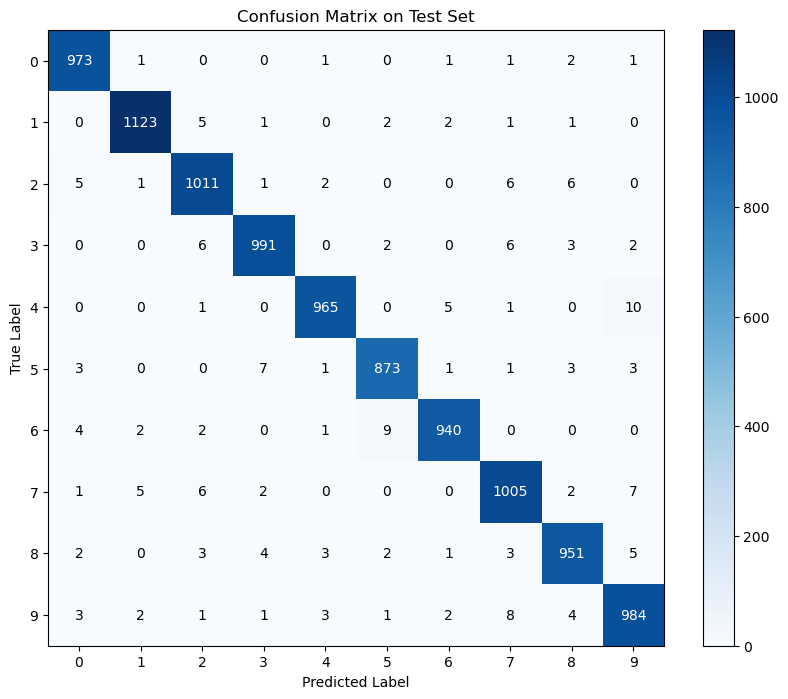

Total misclassifications: 184 out of 10000


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


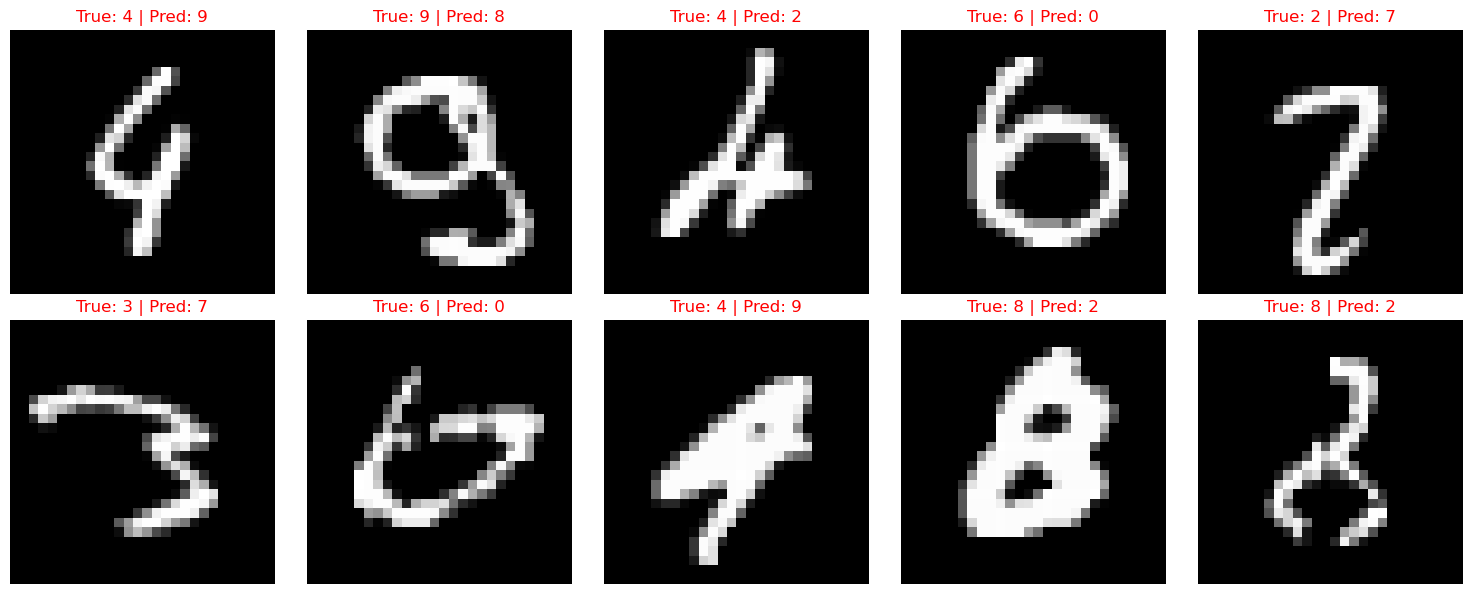

In [25]:
q_2_8_error_analysis()

## 2.10 The Fashion-MNIST Transfer Challenge

In [5]:
def q_2_10_fashion_mnist():
    print("\n" + "="*70)
    print("Question 2.10: Fashion-MNIST Transfer Challenge")
    print("="*70)

    X_train, y_train_oh, _, _ = load_and_preprocess_data('fashion_mnist')

    # Placeholder: You will fill these in once your sweep tells you what works on digits!
    configs_to_test = [
        {
            "name": "config_1_baseline", 
            "layers": 3, 
            "sizes": [128, 128, 64], 
            "opt": "rmsprop", 
            "act": "relu",
            "loss": "mean_squared_error",
            "weight_decay": 0.0001
        },
        {
            "name": "config_2_max_cap_ce",   
            "layers": 3, 
            "sizes": [128, 128, 128], 
            "opt": "rmsprop", 
            "act": "relu",
            "loss": "cross_entropy",
            "weight_decay": 0.0001
        },
        {
            "name": "config_3_high_reg",    
            "layers": 3, 
            "sizes": [128, 128, 128], 
            "opt": "rmsprop", 
            "act": "relu",
            "loss": "cross_entropy",
            "weight_decay": 0.001
        }
    ]

    for config in configs_to_test:
        print(f"\n--- Testing Fashion-MNIST: {config['name']} ---")
        
        wandb.init(
            project=PROJECT_NAME,
            name=f"2.10_fashion_{config['name']}",
            group="fashion_mnist"
        )

        args = MockArgs()
        args.dataset = 'fashion_mnist'
        args.loss = config['loss']
        args.learning_rate = 0.0005223702395699795
        args.weight_decay = config['weight_decay']
        args.optimizer = config['opt']
        args.activation = config['act']
        args.weight_init = 'xavier'
        args.num_layers = config['layers']
        args.hidden_size = config['sizes']

        model = NeuralNetwork(args)
        model.train(X_train, y_train_oh, epochs=15, batch_size=32)

        wandb.finish()

In [6]:
q_2_10_fashion_mnist()


Question 2.10: Fashion-MNIST Transfer Challenge


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Vishnu\_netrc.



--- Testing Fashion-MNIST: config_1_baseline ---


wandb: Currently logged in as: cs25m050 (cs25m050-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch-1: Train Loss = 8.1299, Train Accuracy = 0.8445, Val Accuracy = 0.8393, Val F1 = 0.8363
Epoch-2: Train Loss = 6.0945, Train Accuracy = 0.8748, Val Accuracy = 0.8656, Val F1 = 0.8631
Epoch-3: Train Loss = 5.6750, Train Accuracy = 0.8807, Val Accuracy = 0.8671, Val F1 = 0.8627
Epoch-4: Train Loss = 5.1552, Train Accuracy = 0.8922, Val Accuracy = 0.8792, Val F1 = 0.8795
Epoch-5: Train Loss = 4.8289, Train Accuracy = 0.9004, Val Accuracy = 0.8838, Val F1 = 0.8839
Epoch-6: Train Loss = 5.2818, Train Accuracy = 0.8908, Val Accuracy = 0.8737, Val F1 = 0.8727
Epoch-7: Train Loss = 4.5992, Train Accuracy = 0.9048, Val Accuracy = 0.8838, Val F1 = 0.8827
Epoch-8: Train Loss = 4.5606, Train Accuracy = 0.9050, Val Accuracy = 0.8831, Val F1 = 0.8833
Epoch-9: Train Loss = 4.3468, Train Accuracy = 0.9092, Val Accuracy = 0.8857, Val F1 = 0.8841
Epoch-10: Train Loss = 4.3221, Train Accuracy = 0.9111, Val Accuracy = 0.8859, Val F1 = 0.8853
Epoch-11: Train Loss = 4.5619, Train Accuracy = 0.9067, Val

...


--- Testing Fashion-MNIST: config_3_high_reg ---


Epoch-1: Train Loss = 0.6510, Train Accuracy = 0.7967, Val Accuracy = 0.7945, Val F1 = 0.7974
Epoch-2: Train Loss = 0.5058, Train Accuracy = 0.8615, Val Accuracy = 0.8522, Val F1 = 0.8523
Epoch-3: Train Loss = 0.4479, Train Accuracy = 0.8798, Val Accuracy = 0.8703, Val F1 = 0.8681
Epoch-4: Train Loss = 0.4329, Train Accuracy = 0.8835, Val Accuracy = 0.8688, Val F1 = 0.8673
Epoch-5: Train Loss = 0.4510, Train Accuracy = 0.8679, Val Accuracy = 0.8582, Val F1 = 0.8615
Epoch-6: Train Loss = 0.3975, Train Accuracy = 0.8938, Val Accuracy = 0.8792, Val F1 = 0.8784
Epoch-7: Train Loss = 0.3883, Train Accuracy = 0.8948, Val Accuracy = 0.8781, Val F1 = 0.8795
Epoch-8: Train Loss = 0.3775, Train Accuracy = 0.8980, Val Accuracy = 0.8781, Val F1 = 0.8790
Epoch-9: Train Loss = 0.3718, Train Accuracy = 0.8998, Val Accuracy = 0.8776, Val F1 = 0.8779
Epoch-10: Train Loss = 0.3826, Train Accuracy = 0.8944, Val Accuracy = 0.8779, Val F1 = 0.8784
Epoch-11: Train Loss = 0.3912, Train Accuracy = 0.8916, Val

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch-15: Train Loss = 0.3677, Train Accuracy = 0.9017, Val Accuracy = 0.8773, Val F1 = 0.8763


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
layer_0_activations,█▆▅▄▃▃▃▂▂▂▂▁▁▂▁
layer_0_dead_neurons_pct,▁▂▃▅▅▅▆▆▇▇▇██▇█
layer_0_grad_norm,▆▁▂▇█▃▃▂▃▄▁██▃▅
layer_1_activations,█▆▅▄▃▃▂▂▂▂▂▁▁▁▁
layer_1_dead_neurons_pct,▁▁▁▄▄▃▆▅▅▆▆▆▇██
layer_2_activations,█▇▆▄▃▄▂▃▂▃▂▁▂▁▁
layer_2_dead_neurons_pct,█▃▃▆▅▁█▆▄▆▇▆▇▆▆
train_acc,▁▅▆▆▅▇▇▇▇▇▇▇▇██
train_loss,█▅▃▃▃▂▂▂▁▂▂▂▁▁▁
+3,...
